# Create info.json — Interactive Object & Relationship Mapper

This notebook helps you create an `info.json` file for an RLBench task by:
1. Scanning masks to discover all unique handle IDs
2. Visualizing each handle ID so you can see which object it corresponds to
3. Letting you define object names and relationship types
4. Letting you map handle IDs to object names interactively
5. Saving the result as `info.json`

## Step 1: Configuration

In [2]:
import sys
import numpy as np
from PIL import Image as PILImage
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cv2
import os
import json
from ipywidgets import *
import IPython.display as ipd
from IPython.display import clear_output
import warnings

sys.path.insert(0, '/workspace/src')
import utils.scene_graph_utils as utils
warnings.filterwarnings('ignore')

# ============================================================================
# EDIT THESE
# ============================================================================
DATASET_PATH = '/workspace/datasets/rlbench'
TASK_NAME    = 'put_rubbish_in_bin'
VARIATION    = 0          # variation to scan for handles
EPISODE      = 0
CAMERA       = 'front'
SAMPLE_FRAME = 0          # frame index to use for visualization

# Derived
task_path = os.path.join(DATASET_PATH, TASK_NAME)
info_path = os.path.join(task_path, 'info.json')
print(f'Task path: {task_path}')
print(f'info.json will be saved to: {info_path}')

Task path: /workspace/datasets/rlbench/put_rubbish_in_bin
info.json will be saved to: /workspace/datasets/rlbench/put_rubbish_in_bin/info.json


## Step 2: Discover All Handle IDs
Scan all frames to find every unique mask handle.

In [3]:
demo, image_data = utils.load_episode_data(
    TASK_NAME, VARIATION, EPISODE, DATASET_PATH=DATASET_PATH, CAMERA=CAMERA
)

print(f'Loaded episode: {len(image_data["rgb"])} RGB, {len(image_data["mask"])} mask frames')

# Scan all masks to find unique handles
all_handles = set()
for mask_path in image_data['mask']:
    mask = utils.decode_mask_image(mask_path)
    all_handles.update(int(h) for h in np.unique(mask) if h != 0)

all_handles = sorted(all_handles)
print(f'\nFound {len(all_handles)} unique handle IDs: {all_handles}')

Loaded episode: 129 RGB, 129 mask frames

Found 19 unique handle IDs: [10, 31, 34, 35, 39, 40, 41, 42, 43, 44, 45, 46, 48, 52, 55, 328, 331, 336, 338]


## Step 3: Visualize Each Handle
Browse handles one by one to see which pixels they correspond to.  
The highlighted pixels (vivid colour) show which object each handle ID belongs to.  
Use the slider or type a handle ID to jump directly.

In [ ]:
# ---------- Interactive handle viewer ----------
frame_selector = BoundedIntText(
    value=SAMPLE_FRAME, min=0, max=len(image_data['mask'])-1,
    description='Frame:', step=1
)
handle_slider = IntSlider(
    value=0, min=0, max=len(all_handles)-1,
    description='Handle #:', continuous_update=False
)
handle_id_input = Dropdown(
    options=[(str(h), h) for h in all_handles],
    description='Handle ID:'
)
show_all_btn = Button(description='Show All Handles', button_style='info')
viewer_output = Output()

_vivid_colors = [
    [255, 50, 50], [50, 120, 255], [50, 220, 50], [255, 180, 30],
    [180, 50, 255], [0, 220, 220], [255, 105, 180], [160, 110, 50],
    [255, 255, 80], [100, 255, 180], [255, 128, 0], [0, 180, 120],
]

def _show_handle(frame_idx, handle_id, show_all=False):
    with viewer_output:
        clear_output(wait=True)
        rgb = cv2.imread(image_data['rgb'][frame_idx])
        rgb = cv2.cvtColor(rgb, cv2.COLOR_BGR2RGB)
        mask = utils.decode_mask_image(image_data['mask'][frame_idx])
        
        if show_all:
            # Show all handles in different colors
            overlay = np.zeros_like(rgb, dtype=np.uint8)
            handles_in_frame = sorted(set(int(h) for h in np.unique(mask) if h != 0))
            legend_patches = []
            for ci, hid in enumerate(handles_in_frame):
                color = _vivid_colors[ci % len(_vivid_colors)]
                overlay[mask == hid] = color
                npix = int(np.sum(mask == hid))
                legend_patches.append(mpatches.Patch(
                    color=[c/255 for c in color],
                    label=f'ID {hid} ({npix} px)'
                ))
            blended = cv2.addWeighted(rgb, 0.5, overlay, 0.5, 0)
            fig, ax = plt.subplots(1, 1, figsize=(10, 10))
            ax.imshow(blended)
            ax.set_title(f'Frame {frame_idx} — All {len(handles_in_frame)} handles')
            ax.legend(handles=legend_patches, loc='upper right', fontsize=8,
                      framealpha=0.8)
            ax.axis('off')
            plt.tight_layout()
            plt.show()
        else:
            # Highlight single handle
            obj_mask = (mask == handle_id)
            npix = int(np.sum(obj_mask))
            overlay = np.zeros_like(rgb, dtype=np.uint8)
            overlay[obj_mask] = [255, 50, 50]  # bright red
            blended = cv2.addWeighted(rgb, 0.6, overlay, 0.4, 0)
            # Draw contour
            contour_mask = obj_mask.astype(np.uint8) * 255
            contours, _ = cv2.findContours(contour_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            cv2.drawContours(blended, contours, -1, (255, 255, 0), 2)
            
            fig, axes = plt.subplots(1, 2, figsize=(14, 6))
            axes[0].imshow(blended)
            axes[0].set_title(f'Handle ID = {handle_id} (highlighted, {npix} px)')
            axes[0].axis('off')
            
            # Show mask-only view
            mask_vis = np.zeros_like(rgb)
            mask_vis[obj_mask] = [255, 255, 255]
            axes[1].imshow(mask_vis)
            axes[1].set_title(f'Handle ID = {handle_id} — mask only')
            axes[1].axis('off')
            plt.tight_layout()
            plt.show()
            
            if npix == 0:
                print(f'⚠ Handle {handle_id} has 0 pixels in frame {frame_idx}.')
                print('  Try a different frame — this object may not be visible here.')

def _on_slider(change):
    handle_id_input.value = all_handles[change['new']]

def _on_dropdown(change):
    idx = all_handles.index(change['new'])
    handle_slider.value = idx
    _show_handle(frame_selector.value, change['new'])

def _on_frame(change):
    _show_handle(change['new'], handle_id_input.value)

def _on_show_all(b):
    _show_handle(frame_selector.value, None, show_all=True)

handle_slider.observe(_on_slider, names='value')
handle_id_input.observe(_on_dropdown, names='value')
frame_selector.observe(_on_frame, names='value')
show_all_btn.on_click(_on_show_all)

ipd.display(HBox([frame_selector, handle_slider, handle_id_input, show_all_btn]))
ipd.display(viewer_output)
_show_handle(SAMPLE_FRAME, all_handles[0])

Output()

## Step 4: Define Objects and Relationships

Use the form below to:
1. **Add objects** — logical entities in the scene (e.g. `robot`, `cup_1`, `cup_2`)
2. **Add relationships** — types of interactions (e.g. `holding`, `stacked`)
3. **Map handles → objects** — assign each handle ID to a named object

In [5]:
# ---------- State ----------
defined_objects = []       # list of object name strings
defined_relations = []     # list of relationship name strings
handle_mapping = {}        # {handle_id (int): object_name (str)}

# Load existing info.json if present
if os.path.exists(info_path):
    with open(info_path, 'r') as f:
        existing = json.load(f)
    if 'objects' in existing:
        defined_objects = [v['name'] for v in sorted(existing['objects'].values(),
                          key=lambda x: list(existing['objects'].values()).index(x))]
    if 'relations' in existing:
        defined_relations = [v['name'] for v in sorted(existing['relations'].values(),
                             key=lambda x: list(existing['relations'].values()).index(x))]
    if 'object_mapping' in existing:
        handle_mapping = {int(k): v for k, v in existing['object_mapping'].items()}
    print(f'Loaded existing info.json:')
    print(f'  Objects: {defined_objects}')
    print(f'  Relations: {defined_relations}')
    print(f'  Mappings: {len(handle_mapping)} handles mapped')
else:
    print(f'No existing info.json found. Starting fresh.')

# ---------- Widgets ----------
# Objects
obj_name_input = Text(description='Object:', placeholder='e.g. cup_1')
add_obj_btn = Button(description='Add Object', button_style='success')
remove_obj_btn = Button(description='Remove Last Object', button_style='danger')
obj_list_output = Output()

# Relations
rel_name_input = Text(description='Relation:', placeholder='e.g. holding')
add_rel_btn = Button(description='Add Relation', button_style='success')
remove_rel_btn = Button(description='Remove Last Relation', button_style='danger')
rel_list_output = Output()

# Handle mapping
map_handle_dropdown = Dropdown(
    options=[(str(h), h) for h in all_handles],
    description='Handle ID:'
)
map_object_dropdown = Dropdown(
    options=defined_objects if defined_objects else ['(define objects first)'],
    description='→ Object:'
)
assign_btn = Button(description='Assign Handle', button_style='primary')
unassign_btn = Button(description='Unassign Handle', button_style='warning')
mapping_output = Output()

# Save
save_btn = Button(description='💾 Save info.json', button_style='success',
                  layout=Layout(width='200px', height='40px'))
save_output = Output()

def _refresh_obj_list():
    with obj_list_output:
        clear_output(wait=True)
        if defined_objects:
            print('Objects:', ', '.join(defined_objects))
        else:
            print('Objects: (none defined yet)')
    # Update mapping dropdown
    map_object_dropdown.options = defined_objects if defined_objects else ['(define objects first)']

def _refresh_rel_list():
    with rel_list_output:
        clear_output(wait=True)
        if defined_relations:
            print('Relations:', ', '.join(defined_relations))
        else:
            print('Relations: (none defined yet)')

def _refresh_mapping():
    with mapping_output:
        clear_output(wait=True)
        if handle_mapping:
            print('Handle → Object mappings:')
            for hid in sorted(handle_mapping.keys()):
                print(f'  {hid} → {handle_mapping[hid]}')
            unmapped = [h for h in all_handles if h not in handle_mapping]
            if unmapped:
                print(f'\n  Unmapped handles: {unmapped}')
        else:
            print('No mappings yet. Assign handles to objects above.')

def _add_obj(b):
    name = obj_name_input.value.strip()
    if name and name not in defined_objects:
        defined_objects.append(name)
        obj_name_input.value = ''
    _refresh_obj_list()

def _remove_obj(b):
    if defined_objects:
        removed = defined_objects.pop()
        # Remove mappings that used this object
        for hid in list(handle_mapping.keys()):
            if handle_mapping[hid] == removed:
                del handle_mapping[hid]
    _refresh_obj_list()
    _refresh_mapping()

def _add_rel(b):
    name = rel_name_input.value.strip()
    if name and name not in defined_relations:
        defined_relations.append(name)
        rel_name_input.value = ''
    _refresh_rel_list()

def _remove_rel(b):
    if defined_relations:
        defined_relations.pop()
    _refresh_rel_list()

def _assign_handle(b):
    hid = map_handle_dropdown.value
    obj = map_object_dropdown.value
    if obj and obj != '(define objects first)':
        handle_mapping[hid] = obj
    _refresh_mapping()

def _unassign_handle(b):
    hid = map_handle_dropdown.value
    handle_mapping.pop(hid, None)
    _refresh_mapping()

def _save_info(b):
    with save_output:
        clear_output(wait=True)
        if not defined_objects:
            print('❌ Define at least one object first.')
            return
        if not defined_relations:
            print('❌ Define at least one relationship type first.')
            return
        
        info = {
            'objects': {str(i): {'name': name} for i, name in enumerate(defined_objects)},
            'relations': {str(i): {'name': name} for i, name in enumerate(defined_relations)},
            'object_mapping': {str(hid): name for hid, name in sorted(handle_mapping.items())}
        }
        
        os.makedirs(task_path, exist_ok=True)
        with open(info_path, 'w') as f:
            json.dump(info, f, indent=4)
        
        print(f'✅ Saved info.json to {info_path}')
        print(f'   Objects ({len(defined_objects)}): {defined_objects}')
        print(f'   Relations ({len(defined_relations)}): {defined_relations}')
        print(f'   Mappings ({len(handle_mapping)}): {dict(sorted(handle_mapping.items()))}')
        unmapped = [h for h in all_handles if h not in handle_mapping]
        if unmapped:
            print(f'   ⚠ Unmapped handles (will be ignored): {unmapped}')

add_obj_btn.on_click(_add_obj)
remove_obj_btn.on_click(_remove_obj)
add_rel_btn.on_click(_add_rel)
remove_rel_btn.on_click(_remove_rel)
assign_btn.on_click(_assign_handle)
unassign_btn.on_click(_unassign_handle)
save_btn.on_click(_save_info)

_refresh_obj_list()
_refresh_rel_list()
_refresh_mapping()

print('=== Define Objects ===')
ipd.display(HBox([obj_name_input, add_obj_btn, remove_obj_btn]))
ipd.display(obj_list_output)

print('\n=== Define Relationships ===')
ipd.display(HBox([rel_name_input, add_rel_btn, remove_rel_btn]))
ipd.display(rel_list_output)

print('\n=== Map Handles → Objects ===')
print('(Use the handle viewer above to identify which handle is which object)')
ipd.display(HBox([map_handle_dropdown, map_object_dropdown, assign_btn, unassign_btn]))
ipd.display(mapping_output)

print('\n')
ipd.display(save_btn)
ipd.display(save_output)

No existing info.json found. Starting fresh.
=== Define Objects ===


Output()


=== Define Relationships ===


Output()


=== Map Handles → Objects ===
(Use the handle viewer above to identify which handle is which object)


Output()

Button(button_style='success', description='💾 Save info.json', layout=Layout(height='40px', width='200px'), st…

Output()

## Step 5: Verify
Run this cell to load the saved `info.json` and verify everything looks correct.

✅ info.json loaded successfully from /workspace/datasets/rlbench/put_rubbish_in_bin/info.json
   Objects: ['robot', 'paper', 'trash bin', 'apple_1', 'apple_2']
   Relations: ['holding', 'in']
   Mappings: {31: 'robot', 34: 'robot', 35: 'robot', 328: 'trash bin', 331: 'paper', 336: 'apple_1', 338: 'apple_2'}


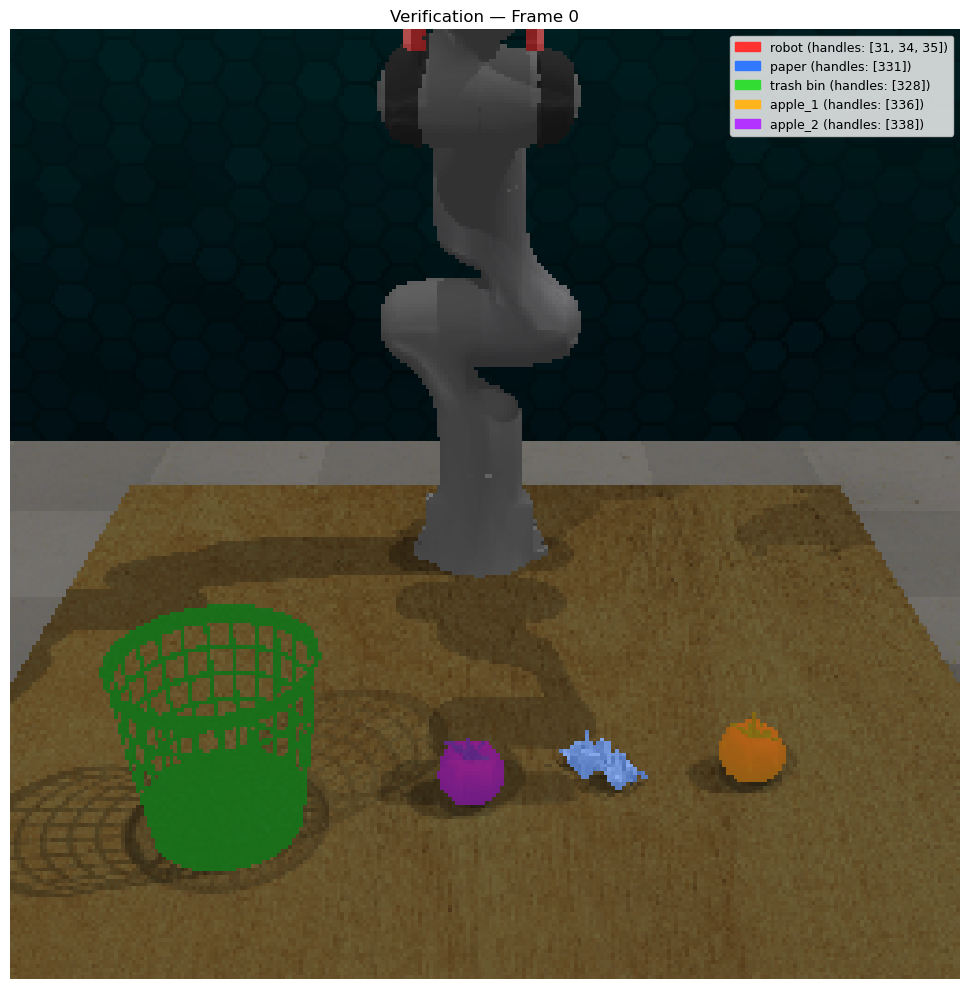

In [9]:
# Verify the saved info.json
if os.path.exists(info_path):
    task_info = utils.load_task_info(task_path)
    print(f'✅ info.json loaded successfully from {info_path}')
    print(f'   Objects: {task_info["object_names"]}')
    print(f'   Relations: {task_info["relationship_types"]}')
    print(f'   Mappings: {task_info["object_mapping"]}')
    
    # Verify with visualization
    objects = task_info['object_names']
    obj_mapping = task_info['object_mapping']
    handles_by_object = {name: [] for name in objects}
    for hid, oname in obj_mapping.items():
        if oname in handles_by_object:
            handles_by_object[oname].append(hid)
    
    # Show verification frame
    fidx = min(SAMPLE_FRAME, len(image_data['mask'])-1)
    rgb = cv2.imread(image_data['rgb'][fidx])
    rgb = cv2.cvtColor(rgb, cv2.COLOR_BGR2RGB)
    mask = utils.decode_mask_image(image_data['mask'][fidx])
    
    overlay = np.zeros_like(rgb, dtype=np.uint8)
    legend_patches = []
    for ci, name in enumerate(objects):
        color = _vivid_colors[ci % len(_vivid_colors)]
        for hid in handles_by_object[name]:
            overlay[mask == hid] = color
        legend_patches.append(mpatches.Patch(
            color=[c/255 for c in color],
            label=f'{name} (handles: {handles_by_object[name]})'
        ))
    blended = cv2.addWeighted(rgb, 0.5, overlay, 0.5, 0)
    
    fig, ax = plt.subplots(1, 1, figsize=(10, 10))
    ax.imshow(blended)
    ax.set_title(f'Verification — Frame {fidx}')
    ax.legend(handles=legend_patches, loc='upper right', fontsize=9, framealpha=0.8)
    ax.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print(f'❌ info.json not found at {info_path}')
    print('   Run Step 4 and click Save first.')